In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=30

In [4]:
dataset=keras.preprocessing.image_dataset_from_directory(
    'Dataset',
    seed=122,
    shuffle=True,
    image_size=(256,256),
    batch_size=32)

Found 2152 files belonging to 3 classes.


In [5]:
len(dataset)   ##total 68 batches of 32 each

68

In [6]:
class_names=dataset.class_names
class_names

['Earlyblight', 'Healthy', 'Lateblight']

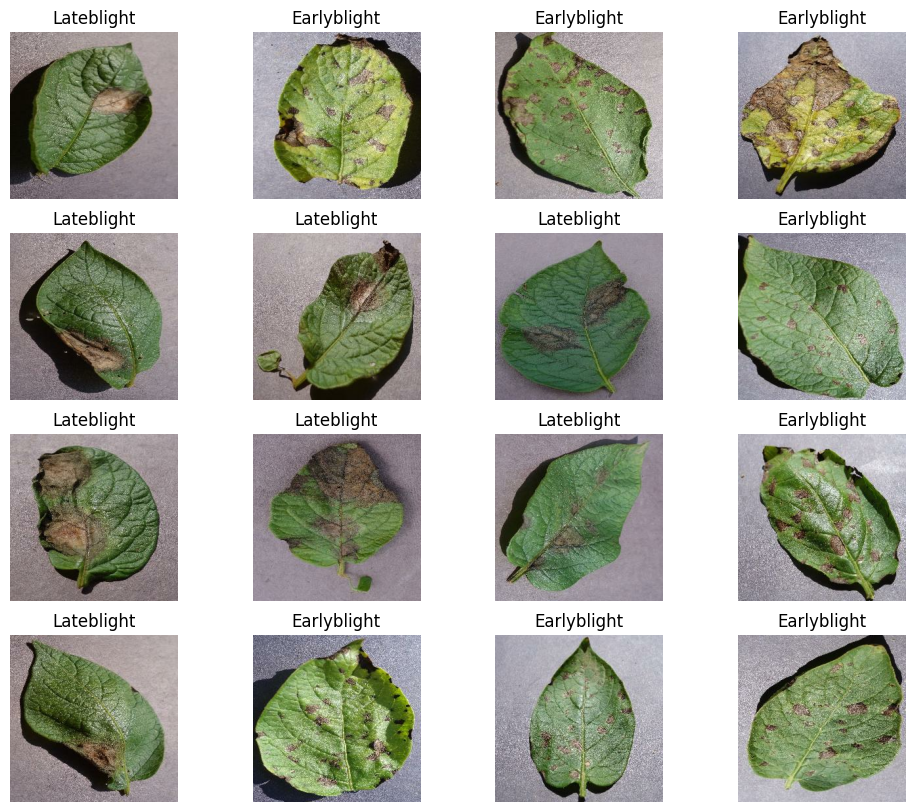

In [7]:
plt.figure(figsize=(12,10))
for image,label in dataset.take(1):
    for i in range(16):
        ax=plt.subplot(4,4,i+1)
        plt.title(class_names[label[i]])
        plt.imshow(image[i]/255)
        plt.axis('off')

In [8]:
### Splitting Data

In [9]:
def split_dataset(ds,train_ratio=0.8,val_ratio=0.1,shuffle=True,shuffle_size=1000):
    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=122)
    total=len(ds)
    train_size=int(train_ratio*total)
    val_size=int(val_ratio*total)
    
    train_ds=ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)
    return train_ds,val_ds,test_ds

In [10]:
train_ds,val_ds,test_ds=split_dataset(dataset)

In [11]:
len(train_ds),len(val_ds),len(test_ds)

(54, 6, 8)

In [12]:
### Cache,shuffle and prefetch

In [13]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [14]:
# transformation of data

In [15]:
resize_scale=keras.Sequential([
    keras.layers.Resizing(256,256),
    keras.layers.Rescaling(1/255.0)
])

In [16]:
augmentation=keras.Sequential([
    keras.layers.RandomFlip('horizontal_and_vertical'),
    keras.layers.RandomRotation(0.2)
])

In [17]:
train_ds=train_ds.map(
    lambda x,y:(augmentation(x,training=True),y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [18]:
### CNN Architecture

In [19]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
model=keras.Sequential([
    resize_scale,
    keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu',input_dim=input_shape),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(3,activation='softmax')
])

C:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [21]:
history=model.fit(train_ds,batch_size=BATCH_SIZE,validation_data=val_ds,epochs=EPOCHS)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.4959 - loss: 0.9436 - val_accuracy: 0.7083 - val_loss: 0.9476
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.5500 - loss: 0.8653 - val_accuracy: 0.6719 - val_loss: 0.7350
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.7257 - loss: 0.6204 - val_accuracy: 0.8177 - val_loss: 0.4033
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.8230 - loss: 0.4521 - val_accuracy: 0.8125 - val_loss: 0.4256
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.8539 - loss: 0.3399 - val_accuracy: 0.8021 - val_loss: 0.4789
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.9105 - loss: 0.2499 - val_accuracy: 0.7292 - val_loss: 0.7235
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.9056 - loss: 0.2407 - val_accuracy: 0.9219 - val_loss: 0.1508
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.9137 - loss: 0.2037 - val_accuracy: 0.9167 - v

In [24]:
model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 448ms/step - accuracy: 0.9486 - loss: 0.1772


[0.18615344166755676, 0.94921875]

In [25]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 54}

In [26]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

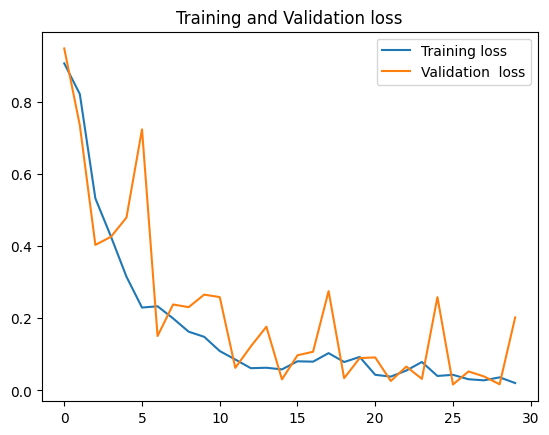

In [32]:
plt.title('Training and Validation loss')
plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'],label='Validation  loss')
plt.legend(loc='upper right')
plt.show()

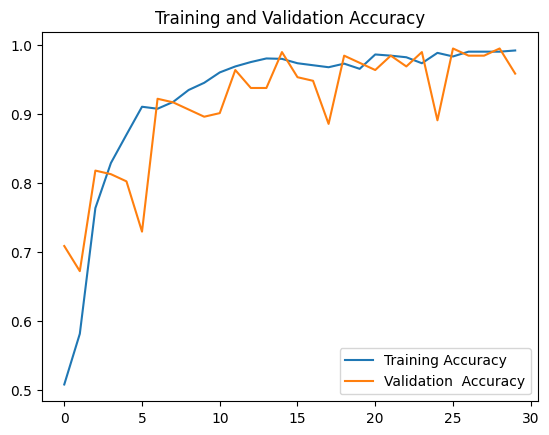

In [35]:
plt.title('Training and Validation Accuracy')
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation  Accuracy')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

history2 = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    epochs=5,
    validation_data=val_ds,
    callbacks=[checkpoint]
)